         SCENARIO 1 – BAGGING (Diabetes Dataset)

📋 Dataset Overview:
   Shape : (120, 6)
   Columns: ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin', 'Outcome']

   First 5 rows:
   Glucose   BMI  Age  BloodPressure  Insulin  Outcome
0      182  21.1   45             99      100        1
1      131  35.6   67             92      199        1
2      172  19.6   68             68      234        1
3       94  39.7   21            102       83        0
4      186  35.0   20            113       61        1

   Missing values:
Glucose          0
BMI              0
Age              0
BloodPressure    0
Insulin          0
Outcome          0
dtype: int64

   Target distribution:
Outcome
1    74
0    46
Name: count, dtype: int64

📊 Train size: 96 | Test size: 24

─────────────────────────────────────────────
  Decision Tree Results
─────────────────────────────────────────────
  Accuracy : 0.9583 (95.83%)
              precision    recall  f1-score   support

 No Diabetes       0.90     

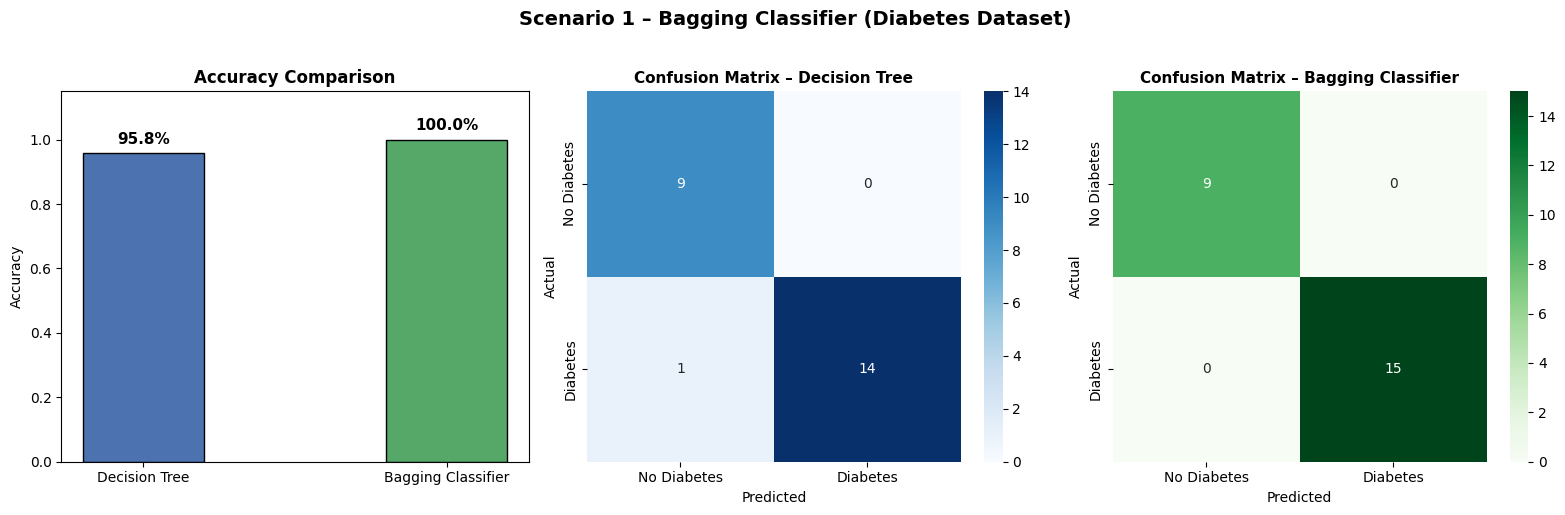


✅ Plot saved → scenario1_bagging_diabetes.png

  SUMMARY
  Decision Tree Accuracy  : 95.83%
  Bagging Classifier Acc  : 100.00%
  Improvement             : +4.17%


In [10]:
# ============================================================
# SCENARIO 1 – Bagging Classifier
# Problem: Predict whether a patient has diabetes
# Dataset: Diabetes Dataset (diabetes_bagging.csv)
# Target: Outcome (0 = No Diabetes, 1 = Diabetes)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ── 1. Load Dataset ──────────────────────────────────────────
df = pd.read_csv("/Users/manojmj/PycharmProjects/machinelearning subject/expno6/dataset/diabetes_bagging.csv")

print("         SCENARIO 1 – BAGGING (Diabetes Dataset)")

print("\n📋 Dataset Overview:")
print(f"   Shape : {df.shape}")
print(f"   Columns: {list(df.columns)}")
print(f"\n   First 5 rows:\n{df.head()}")
print(f"\n   Missing values:\n{df.isnull().sum()}")
print(f"\n   Target distribution:\n{df['Outcome'].value_counts()}")

# ── 2. Prepare Features & Target ─────────────────────────────
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# ── 3. Train Decision Tree (baseline) ────────────────────────
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc  = accuracy_score(y_test, dt_pred)

print("\n" + "─" * 45)
print("  Decision Tree Results")
print("─" * 45)
print(f"  Accuracy : {dt_acc:.4f} ({dt_acc*100:.2f}%)")
print(classification_report(y_test, dt_pred, target_names=["No Diabetes", "Diabetes"]))

# ── 4. Train BaggingClassifier ───────────────────────────────
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    random_state=42
)
bag.fit(X_train, y_train)
bag_pred = bag.predict(X_test)
bag_acc  = accuracy_score(y_test, bag_pred)

print("─" * 45)
print("  BaggingClassifier Results (n_estimators=50)")
print("─" * 45)
print(f"  Accuracy : {bag_acc:.4f} ({bag_acc*100:.2f}%)")
print(classification_report(y_test, bag_pred, target_names=["No Diabetes", "Diabetes"]))

# ── 5. Visualizations ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Scenario 1 – Bagging Classifier (Diabetes Dataset)",
             fontsize=14, fontweight="bold", y=1.02)

# (a) Accuracy Comparison Bar Graph
models  = ["Decision Tree", "Bagging Classifier"]
accuracies = [dt_acc, bag_acc]
colors  = ["#4C72B0", "#55A868"]
bars = axes[0].bar(models, accuracies, color=colors, width=0.4, edgecolor="black")
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Accuracy Comparison", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Accuracy")
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.02,
                 f"{acc*100:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_ylim(0, 1.15)

# (b) Confusion Matrix – Decision Tree
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
axes[1].set_title("Confusion Matrix – Decision Tree", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# (c) Confusion Matrix – Bagging
cm_bag = confusion_matrix(y_test, bag_pred)
sns.heatmap(cm_bag, annot=True, fmt="d", cmap="Greens", ax=axes[2],
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
axes[2].set_title("Confusion Matrix – Bagging Classifier", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("scenario1_bagging_diabetes.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Plot saved → scenario1_bagging_diabetes.png")

# ── 6. Summary ───────────────────────────────────────────────
improvement = (bag_acc - dt_acc) * 100
print("\n" + "=" * 55)
print("  SUMMARY")
print("=" * 55)
print(f"  Decision Tree Accuracy  : {dt_acc*100:.2f}%")
print(f"  Bagging Classifier Acc  : {bag_acc*100:.2f}%")
print(f"  Improvement             : {improvement:+.2f}%")
print("=" * 55)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [12]:
df = pd.read_csv("/Users/manojmj/PycharmProjects/machinelearning subject/expno6/dataset/diabetes_bagging.csv")

print("         SCENARIO 1 – BAGGING (Diabetes Dataset)")

print("\n📋 Dataset Overview:")
print(f"   Shape : {df.shape}")
print(f"   Columns: {list(df.columns)}")
print(f"\n   First 5 rows:\n{df.head()}")
print(f"\n   Missing values:\n{df.isnull().sum()}")
print(f"\n   Target distribution:\n{df['Outcome'].value_counts()}")

         SCENARIO 1 – BAGGING (Diabetes Dataset)

📋 Dataset Overview:
   Shape : (120, 6)
   Columns: ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin', 'Outcome']

   First 5 rows:
   Glucose   BMI  Age  BloodPressure  Insulin  Outcome
0      182  21.1   45             99      100        1
1      131  35.6   67             92      199        1
2      172  19.6   68             68      234        1
3       94  39.7   21            102       83        0
4      186  35.0   20            113       61        1

   Missing values:
Glucose          0
BMI              0
Age              0
BloodPressure    0
Insulin          0
Outcome          0
dtype: int64

   Target distribution:
Outcome
1    74
0    46
Name: count, dtype: int64


In [13]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")


📊 Train size: 96 | Test size: 24


In [14]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc  = accuracy_score(y_test, dt_pred)

print("\n" + "─" * 45)
print("  Decision Tree Results")
print("─" * 45)
print(f"  Accuracy : {dt_acc:.4f} ({dt_acc*100:.2f}%)")
print(classification_report(y_test, dt_pred, target_names=["No Diabetes", "Diabetes"]))



─────────────────────────────────────────────
  Decision Tree Results
─────────────────────────────────────────────
  Accuracy : 0.9583 (95.83%)
              precision    recall  f1-score   support

 No Diabetes       0.90      1.00      0.95         9
    Diabetes       1.00      0.93      0.97        15

    accuracy                           0.96        24
   macro avg       0.95      0.97      0.96        24
weighted avg       0.96      0.96      0.96        24

